# **Métodos ensemble**

Profesor: **D.Sc. Pastor Enmanuel Pérez Estigarribia**

**CONTENIDO**

1.   Métodos voting, bagging, boosting, stacking.
2.   Aplicación de métodos ensemble con Python.

**OBJETIVOS:**


**Conceptuales**

Entender el funcionamiento de los métodos ensemble.

**Procedimentales:**

Aplicar métodos ensemble empleando Python.

**Actitudinales:**

Aprovechar las capacidades de Python para aplicar métodos ensemble.


 # **Voting Ensembles con Python**

 En este tutorial, descubrirá cómo crear [*Voting Ensembles*](https://machinelearningmastery.com/voting-ensembles-with-python/#:~:text=A%20voting%20ensemble%20(or%20a,model%20used%20in%20the%20ensemble) para algoritmos de aprendizaje automático en Python.

 Después de completar este tutorial, sabrás qué:

- *Voting Ensembles* implica sumar las predicciones realizadas por los modelos de clasificación o promediar las predicciones realizadas por los modelos de regresión.
- Cómo funcionan los *Voting Ensembles*, cuándo usarlos y las limitaciones del enfoque.
- Cómo implementar un *Voting Ensembles* fuerte y un *Voting Ensembles* blanda para un modelado predictivo de clasificación.

## **Voting Ensemble Scikit-Learn API**

La biblioteca de aprendizaje automático de Python de scikit-learn proporciona una implementación de votación para el aprendizaje automático.

Primero vamos a confirmar la versión de la biblioteca ejecutando el siguiente script:

In [ ]:
# check scikit-learn version
import sklearn
print(sklearn.__version__)

1.2.2


La votación se proporciona a través de las clases  *VotingRegressor* y *VotingClassifier*.

Se proporciona una lista de modelos base a través del argumento “estimators”. Esta es una lista de Python donde cada elemento de la lista es una tupla con el nombre del modelo y la instancia del modelo configurado. Cada modelo en la lista debe tener un nombre único.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

models = [('lr',LogisticRegression()),('svm',SVC())]
ensemble = VotingClassifier(estimators=models)
type(ensemble)

sklearn.ensemble._voting.VotingClassifier

Cada modelo de la lista también puede ser un Pipeline , incluida cualquier preparación de datos requerida por el modelo antes de ajustar el modelo en el conjunto de datos de entrenamiento.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models = [('lr',LogisticRegression()),('svm',make_pipeline(StandardScaler(),SVC()))]
ensemble = VotingClassifier(estimators=models)

Cuando se utiliza un conjunto de votación para la clasificación, el tipo de votación, como la votación dura o la votación blanda, se puede especificar a través del argumento “voting” y establecer la cadena ‘hard‘  (predeterminada) o  ‘soft‘.

In [ ]:
models = [('lr',LogisticRegression()),('svm',SVC())]
ensemble = VotingClassifier(estimators=models, voting='soft')

## **Voting Ensemble para clasificación**

Primero, podemos usar la función make_classification() para crear un problema de clasificación binaria sintética con 1000 ejemplos y 20 características de entrada.

In [ ]:
# test classification dataset
from sklearn.datasets import make_classification
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


### **Hard Voting Ensemble para clasificación**

Podemos adaptar cinco versiones diferentes del algoritmo KNN, cada una con un número diferente de vecinos utilizados al hacer predicciones. Usaremos 1, 3, 5, 7 y 9 vecinos (números impares en un intento de evitar empates).

Primero, podemos crear una función llamada get_voting() que crea cada modelo KNN y combina los modelos en un conjunto de votación dura.


<img src='https://miro.medium.com/v2/resize:fit:720/format:webp/0*34SajbTO2C5Lvigs.png'>

<img src='https://miro.medium.com/v2/resize:fit:640/format:webp/0*zCnwFe1zL2tGN5oi.png'>


Fuente: https://medium.com/swlh/k-nearest-neighbor-ca2593d7a3c4



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# get a voting ensemble of models
def get_voting():
 # define the base models
 models = list()
 models.append(('knn1', KNeighborsClassifier(n_neighbors=1)))
 models.append(('knn3', KNeighborsClassifier(n_neighbors=3)))
 models.append(('knn5', KNeighborsClassifier(n_neighbors=5)))
 models.append(('knn7', KNeighborsClassifier(n_neighbors=7)))
 models.append(('knn9', KNeighborsClassifier(n_neighbors=9)))
 # define the voting ensemble
 ensemble = VotingClassifier(estimators=models, voting='hard')
 return ensemble

Luego, podemos crear una lista de modelos para evaluar, incluida cada versión independiente de las configuraciones del modelo KNN y el conjunto de votación dura.

In [ ]:
# get a list of models to evaluate
def get_models():
 models = dict()
 models['knn1'] = KNeighborsClassifier(n_neighbors=1)
 models['knn3'] = KNeighborsClassifier(n_neighbors=3)
 models['knn5'] = KNeighborsClassifier(n_neighbors=5)
 models['knn7'] = KNeighborsClassifier(n_neighbors=7)
 models['knn9'] = KNeighborsClassifier(n_neighbors=9)
 models['hard_voting'] = get_voting()
 return models

Cada modelo se evaluará utilizando una validación cruzada repetida de k-fold .

La función evaluate_model() toma una instancia de modelo y la devuelve como una lista de puntajes de tres repeticiones de validación cruzada estratificada de 10-fold.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
 return scores

A continuación, podemos informar el rendimiento medio de cada algoritmo y también crear un gráfico de caja y bigotes para comparar la distribución de las puntuaciones de precisión de cada algoritmo. El codigo completo se muestra a continuación

>knn1 0.907 (0.026)
>knn3 0.920 (0.025)
>knn5 0.929 (0.022)
>knn7 0.928 (0.021)
>knn9 0.928 (0.021)
>hard_voting 0.935 (0.022)


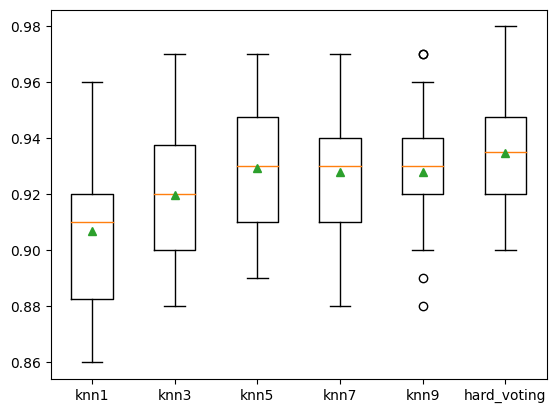

In [ ]:

# compare hard voting to standalone classifiers
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=17, n_redundant=3, random_state=3)
 return X, y

# get a voting ensemble of models
def get_voting():
 # define the base models
 models = list()
 models.append(('knn1', KNeighborsClassifier(n_neighbors=1)))
 models.append(('knn3', KNeighborsClassifier(n_neighbors=3)))
 models.append(('knn5', KNeighborsClassifier(n_neighbors=5)))
 models.append(('knn7', KNeighborsClassifier(n_neighbors=7)))
 models.append(('knn9', KNeighborsClassifier(n_neighbors=9)))
 # define the voting ensemble
 ensemble = VotingClassifier(estimators=models, voting='hard')
 return ensemble

# get a list of models to evaluate
def get_models():
 models = dict()
 models['knn1'] = KNeighborsClassifier(n_neighbors=1)
 models['knn3'] = KNeighborsClassifier(n_neighbors=3)
 models['knn5'] = KNeighborsClassifier(n_neighbors=5)
 models['knn7'] = KNeighborsClassifier(n_neighbors=7)
 models['knn9'] = KNeighborsClassifier(n_neighbors=9)
 models['hard_voting'] = get_voting()
 return models

# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 scores = evaluate_model(model, X, y)
 results.append(scores)
 names.append(name)
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

Si elegimos un conjunto de votación dura como nuestro modelo final, podemos ajustarlo y usarlo para hacer predicciones sobre nuevos datos como cualquier otro modelo.

Primero, el conjunto de votación dura se ajusta a todos los datos disponibles, luego se puede llamar a la función predict() para hacer predicciones sobre nuevos datos.

In [ ]:
# make a prediction with a hard voting ensemble
from sklearn.datasets import make_classification
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)
# define the base models
models = list()
models.append(('knn1', KNeighborsClassifier(n_neighbors=1)))
models.append(('knn3', KNeighborsClassifier(n_neighbors=3)))
models.append(('knn5', KNeighborsClassifier(n_neighbors=5)))
models.append(('knn7', KNeighborsClassifier(n_neighbors=7)))
models.append(('knn9', KNeighborsClassifier(n_neighbors=9)))
# define the hard voting ensemble
ensemble = VotingClassifier(estimators=models, voting='hard')
# fit the model on all available data
ensemble.fit(X, y)
# make a prediction for one example
data = [[5.88891819,2.64867662,-0.42728226,-1.24988856,-0.00822,-3.57895574,2.87938412,-1.55614691,-0.38168784,7.50285659,-1.16710354,-5.02492712,-0.46196105,-0.64539455,-1.71297469,0.25987852,-0.193401,-5.52022952,0.0364453,-1.960039]]
yhat = ensemble.predict(data)
print('Predicted Class: %d' % (yhat))

Predicted Class: 1


### **Soft Voting Ensemble para clasificación**

El algoritmo [SVM]('https://scikit-learn.org/stable/modules/svm.html#:~:text=Support%20vector%20machines%20(SVMs)%20are,Effective%20in%20high%20dimensional%20spaces.') no predice probabilidades de forma nativa, aunque se puede configurar para predecir puntajes similares a probabilidades configurando el argumento “probability” en “True” en la clase SVC.

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_iris_svc_001.png'>

Fuente: https://scikit-learn.org/stable/modules/svm.html#:~:text=Support%20vector%20machines%20(SVMs)%20are,Effective%20in%20high%20dimensional%20spaces.


<img src='https://miro.medium.com/v2/resize:fit:600/format:webp/0*9jEWNXTAao7phK-5.png'>

<img src='https://miro.medium.com/v2/resize:fit:720/format:webp/1*ZpkLQf2FNfzfH4HXeMw4MQ.png'>

Fuente: https://towardsdatascience.com/support-vector-machine-introduction-to-machine-learning-algorithms-934a444fca47

Veamos entonces un ejemplo a continuación


>svm1 0.855 (0.035)
>svm2 0.859 (0.034)
>svm3 0.890 (0.035)
>svm4 0.808 (0.037)
>svm5 0.850 (0.037)
>soft_voting 0.925 (0.026)


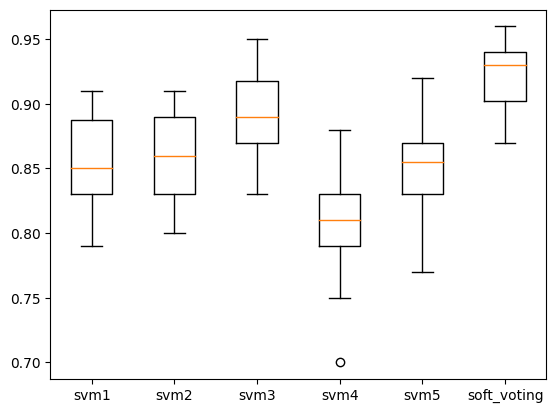

In [ ]:

# compare soft voting ensemble to standalone classifiers
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)
 return X, y

# get a voting ensemble of models
def get_voting():
 # define the base models
 models = list()
 models.append(('svm1', SVC(probability=True, kernel='poly', degree=1)))
 models.append(('svm2', SVC(probability=True, kernel='poly', degree=2)))
 models.append(('svm3', SVC(probability=True, kernel='poly', degree=3)))
 models.append(('svm4', SVC(probability=True, kernel='poly', degree=4)))
 models.append(('svm5', SVC(probability=True, kernel='poly', degree=5)))
 # define the voting ensemble
 ensemble = VotingClassifier(estimators=models, voting='soft')
 return ensemble

# get a list of models to evaluate
def get_models():
 models = dict()
 models['svm1'] = SVC(probability=True, kernel='poly', degree=1)
 models['svm2'] = SVC(probability=True, kernel='poly', degree=2)
 models['svm3'] = SVC(probability=True, kernel='poly', degree=3)
 models['svm4'] = SVC(probability=True, kernel='poly', degree=4)
 models['svm5'] = SVC(probability=True, kernel='poly', degree=5)
 models['soft_voting'] = get_voting()
 return models

# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 scores = evaluate_model(model, X, y)
 results.append(scores)
 names.append(name)
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=False)
pyplot.show()

Podemos aplicar el modelo a una predicción

In [ ]:

# make a prediction with a soft voting ensemble
from sklearn.datasets import make_classification
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)
# define the base models
models = list()
models.append(('svm1', SVC(probability=True, kernel='poly', degree=1)))
models.append(('svm2', SVC(probability=True, kernel='poly', degree=2)))
models.append(('svm3', SVC(probability=True, kernel='poly', degree=3)))
models.append(('svm4', SVC(probability=True, kernel='poly', degree=4)))
models.append(('svm5', SVC(probability=True, kernel='poly', degree=5)))
# define the soft voting ensemble
ensemble = VotingClassifier(estimators=models, voting='soft')
# fit the model on all available data
ensemble.fit(X, y)
# make a prediction for one example
data = [[5.88891819,2.64867662,-0.42728226,-1.24988856,-0.00822,-3.57895574,2.87938412,-1.55614691,-0.38168784,7.50285659,-1.16710354,-5.02492712,-0.46196105,-0.64539455,-1.71297469,0.25987852,-0.193401,-5.52022952,0.0364453,-1.960039]]
yhat = ensemble.predict(data)
print('Predicted Class: %d' % (yhat))

Predicted Class: 1


### **Voting Ensemble para regresión**

Modelos de regresión:

- https://phet.colorado.edu/sims/html/least-squares-regression/latest/least-squares-regression_all.html?locale=es

- https://phet.colorado.edu/sims/html/least-squares-regression/latest/least-squares-regression-900-alt1.png

- https://phet.colorado.edu/sims/html/curve-fitting/latest/curve-fitting_all.html?locale=es



Primero, podemos usar la función make_regression() para crear un problema de regresión sintética con 1000 ejemplos y 20 características de entrada.

In [ ]:
# test regression dataset
from sklearn.datasets import make_regression
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=1)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


Podemos demostrar la votación en conjunto para la regresión con un algoritmo de árbol de decisión, a veces denominado algoritmo de árbol de clasificación y regresión (CART).

Ver: https://rubenfcasal.github.io/aprendizaje_estadistico/%C3%A1rboles-de-regresi%C3%B3n-cart.html

Podemos ajustar cinco versiones diferentes del algoritmo CART, cada una con una profundidad máxima diferente del árbol de decisión, establecida a través del argumento " max_depth ". Usaremos profundidades de 1-5.

Podemos evaluar y reportar el desempeño del modelo usando una validación cruzada repetida de k-fold como lo hicimos en la sección anterior.

Los modelos se evalúan utilizando el **error absoluto medio (MAE)**. El scikit-learn hace que la puntuación sea negativa para que pueda maximizarse. Esto significa que las puntuaciones MAE notificadas son negativas, **los valores más grandes son mejores** y 0 no representa ningún error.

>cart1 -161.519 (11.414)
>cart2 -152.596 (11.271)
>cart3 -142.378 (10.900)
>cart4 -140.086 (12.469)
>cart5 -137.360 (12.186)
>voting -136.337 (11.246)


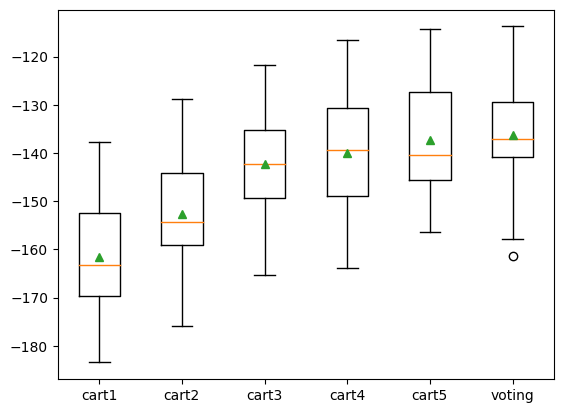

In [ ]:

# compare voting ensemble to each standalone models for regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=1)
 return X, y

# get a voting ensemble of models
def get_voting():
 # define the base models
 models = list()
 models.append(('cart1', DecisionTreeRegressor(max_depth=1)))
 models.append(('cart2', DecisionTreeRegressor(max_depth=2)))
 models.append(('cart3', DecisionTreeRegressor(max_depth=3)))
 models.append(('cart4', DecisionTreeRegressor(max_depth=4)))
 models.append(('cart5', DecisionTreeRegressor(max_depth=5)))
 # define the voting ensemble
 ensemble = VotingRegressor(estimators=models)
 return ensemble

# get a list of models to evaluate
def get_models():
 models = dict()
 models['cart1'] = DecisionTreeRegressor(max_depth=1)
 models['cart2'] = DecisionTreeRegressor(max_depth=2)
 models['cart3'] = DecisionTreeRegressor(max_depth=3)
 models['cart4'] = DecisionTreeRegressor(max_depth=4)
 models['cart5'] = DecisionTreeRegressor(max_depth=5)
 models['voting'] = get_voting()
 return models

# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, error_score='raise')
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 scores = evaluate_model(model, X, y)
 results.append(scores)
 names.append(name)
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

Podemos aplicarlo a una predicción con el siguiente codigo

In [ ]:
# make a prediction with a voting ensemble
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=1)
# define the base models
models = list()
models.append(('cart1', DecisionTreeRegressor(max_depth=1)))
models.append(('cart2', DecisionTreeRegressor(max_depth=2)))
models.append(('cart3', DecisionTreeRegressor(max_depth=3)))
models.append(('cart4', DecisionTreeRegressor(max_depth=4)))
models.append(('cart5', DecisionTreeRegressor(max_depth=5)))
# define the voting ensemble
ensemble = VotingRegressor(estimators=models)
# fit the model on all available data
ensemble.fit(X, y)
# make a prediction for one example
data = [[0.59332206,-0.56637507,1.34808718,-0.57054047,-0.72480487,1.05648449,0.77744852,0.07361796,0.88398267,2.02843157,1.01902732,0.11227799,0.94218853,0.26741783,0.91458143,-0.72759572,1.08842814,-0.61450942,-0.69387293,1.69169009]]
yhat = ensemble.predict(data)
print('Predicted Value: %.3f' % (yhat))

Predicted Value: 141.319
